---
title: "🧊 Data loading, preperation and cleanup CNN"
author: "Maksim Ohvrill"
date: "4/28/2025"
format:
  html:
    toc: true
    toc-location: right
    code-fold: true
bibliography: references.bib
csl: ieee-with-url.csl
jupyter: Python
---

## **Multilabel classification data-preprocessing**

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

from CNN import OUT_DIR, XRAY_DIR, CSV_PATH

def load_data(csv_path):
    df = pd.read_csv(csv_path)
    rename_map = {
        "Image Index": "IMGPATH",
        "Finding Labels": "DISEASELABEL",
        "Follow-up #": "FOLLOWUP",
        "Patient ID": "PATID",
        "Patient Age": "AGE",
        "Patient Gender": "GENDER",
        "View Position": "VP",
    }
    df = df.rename(columns=rename_map)
    return df

def find_full_path(image_name):
    for subdir in os.listdir(XRAY_DIR):
        full_path = os.path.join(XRAY_DIR, subdir, image_name)
        if os.path.exists(full_path):
            return full_path
    return None

def filter_selected_classes(df, selected_classes):
    include_only_pure = False
    df["DISEASELABEL"] = df["DISEASELABEL"].apply(lambda x: x.split("|") if isinstance(x, str) else [x])
    if include_only_pure:
        df = df[df["DISEASELABEL"].apply(lambda labels: len(labels) == 1 and labels[0] in selected_classes)].copy()
    else:
        df = df[df["DISEASELABEL"].apply(lambda labels: any(label in selected_classes or label == "No Finding" for label in labels))].copy()
    return df

def assign_multilabel_vector(df, class_list):
    def create_vector(labels):
        return [int(cls in labels) for cls in class_list]
    df["MULTIHOT"] = df["DISEASELABEL"].apply(create_vector)
    df = df[[
        "IMGPATH",
        "DISEASELABEL",
        "MULTIHOT",
        "FOLLOWUP",
        "PATID",
        "AGE",
        "GENDER",
        "VP",
    ]]
    return df

def patient_aware_split(df, test_size=0.08, val_size=0.12):
    no_findings = df[df["DISEASELABEL"].apply(lambda x: x == ["No Finding"])]
    findings = df[df["DISEASELABEL"].apply(lambda x: "No Finding" not in x)]

    df_balanced = pd.concat([findings, no_findings.sample(frac=0.3, random_state=42)])
    unique_patients = df_balanced["PATID"].unique()

    train_val_patients, test_patients = train_test_split(
        unique_patients, test_size=test_size, random_state=42
    )
    train_patients, val_patients = train_test_split(
        train_val_patients, test_size=val_size / (1 - test_size), random_state=42
    )
    train_df = df_balanced[df_balanced["PATID"].isin(train_patients)]
    val_df = df_balanced[df_balanced["PATID"].isin(val_patients)]
    test_df = df_balanced[df_balanced["PATID"].isin(test_patients)]
    return train_df, val_df, test_df

def preprocess_data(csv_path):
    selected_classes = ["Effusion", "Atelectasis"]
    df = load_data(csv_path)
    df["IMGPATH"] = df["IMGPATH"].apply(find_full_path)
    df = filter_selected_classes(df, selected_classes)
    df = assign_multilabel_vector(df, selected_classes)
    train_df, val_df, test_df = patient_aware_split(df)
    return train_df, val_df, test_df

train_df, val_df, test_df = preprocess_data(CSV_PATH)

train_df.to_csv(OUT_DIR / "ml_train.csv", index=False)
val_df.to_csv(OUT_DIR / "ml_val.csv", index=False)
test_df.to_csv(OUT_DIR / "ml_test.csv", index=False)


## **Patient overlap check**

In [ ]:
from rich import print
# Check for patient ID overlaps
train_pids = set(train_df["PATID"])
val_pids = set(val_df["PATID"])
test_pids = set(test_df["PATID"])

overlap_train_val = train_pids & val_pids
overlap_train_test = train_pids & test_pids
overlap_val_test   = val_pids & test_pids

if overlap_train_val or overlap_train_test or overlap_val_test:
    print("[bold red]⚠️ Patient ID Overlap Detected Between Splits:[/bold red]")
    if overlap_train_val:
        print(f"[yellow]- Train ↔ Validation:[/] {len(overlap_train_val)} overlapping patient(s)")
    if overlap_train_test:
        print(f"[yellow]- Train ↔ Test:[/] {len(overlap_train_test)} overlapping patient(s)")
    if overlap_val_test:
        print(f"[yellow]- Validation ↔ Test:[/] {len(overlap_val_test)} overlapping patient(s)")
else:
    print("[bold green]✅ No patient ID overlap across splits.[/bold green]")

## **Data stats heatmap**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def multilabel_stats(df, name):
    return pd.Series({
        "Total": len(df),
        "No finding": df["MULTIHOT"].apply(lambda x: x[0] == 0 and x[1] == 0).sum(),
        "Effusion": df["MULTIHOT"].apply(lambda x: x[0]).sum(),
        "Atelectasis": df["MULTIHOT"].apply(lambda x: x[1]).sum(),
        "Both": df["MULTIHOT"].apply(lambda x: x[0] == 1 and x[1] == 1).sum(),
        "Unique Patients": df["PATID"].nunique(),
        "Median Age": df["AGE"].median(),
        "Male %": (df["GENDER"] == "M").mean() * 100,
        "PA View %": (df["VP"] == "PA").mean() * 100,
        "Unique Labels": df["DISEASELABEL"].apply(str).nunique()
    }, name=name)

summary_df = pd.concat([
    multilabel_stats(train_df, "Train"),
    multilabel_stats(val_df, "Validation"),
    multilabel_stats(test_df, "Test")
], axis=1).T

heatmap_data = summary_df.astype(int)

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    linewidths=0.5,
    linecolor="white"
)

plt.title("Multilabel Summary Statistics per Split")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **Compute mean & std values for x-ray images**

Computing mean and std (method 2): 100%|██████████| 95/95 [00:25<00:00,  3.68it/s]


Method 1 - Average mean: 0.50509, Average std: 0.22978

Method 2 - Mean: 0.50509, Std: 0.24930

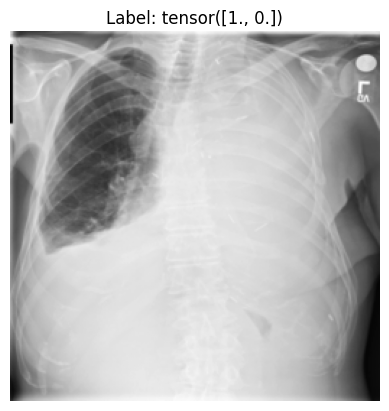

In [2]:
import pandas as pd
from PIL import Image
from tqdm import tqdm
from rich import print
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torchvision.transforms.functional as TF

from CNN import ChestXRayDataset, OUT_DIR

# First method: manual per-image mean/std
def calc_mean_std(img_path: str) -> tuple[float, float]:
    img = Image.open(img_path).convert("L")
    img = T.Resize((256, 256))(img)
    tensor = TF.to_tensor(img)
    mean = tensor.mean().item()
    std = tensor.std().item()
    return mean, std

df = pd.read_csv(OUT_DIR / "ml_test.csv")

means = []
stds = []

for img_path in tqdm(df["IMGPATH"], desc="Computing mean and std (method 1)"):
    mean, std = calc_mean_std(img_path)
    means.append(mean)
    stds.append(std)

avg_mean = sum(means) / len(means)
avg_std = sum(stds) / len(stds)

# Second method: dataset-wide mean/std via DataLoader devided by 32 batches

train_dt = ChestXRayDataset(OUT_DIR / "ml_test.csv", transform=False)

def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    psum = 0.0
    psum_sq = 0.0
    count = 0

    for imgs, _ in tqdm(loader, desc="Computing mean and std (method 2)"):
        imgs = imgs.float().cpu()
        psum += imgs.sum().item()
        psum_sq += (imgs ** 2).sum().item()
        count += imgs.numel()

    mean = psum / count
    std = ((psum_sq / count) - (mean ** 2)) ** 0.5
    return mean, std

mean2, std2 = compute_mean_std(train_dt)

print(f"\nMethod 1 - Average mean: {avg_mean:.5f}, Average std: {avg_std:.5f}")
print(f"Method 2 - Mean: {mean2:.5f}, Std: {std2:.5f}")

# View one sample image
img, label = train_dt[0]
plt.imshow(img.squeeze(0), cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()
